### Introduction & Objectives
**Objective:** Merge the Red and White wine datasets and use K-means clustering to distinguish between the two wine types based purely on their chemical properties.

In this notebook, we perform Descriptive Statistics, Exploratory Data Analysis (EDA), and Anomaly Detection. We then apply standard scaling and K-Means ($k=2$) clustering, evaluating the clustering validity using a Confusion Matrix, Accuracy, and Sensitivity metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### Data Loading & Merging
We load both datasets, inject a categorical `type` column to serve as our ground truth for later evaluation, and merge them.

In [7]:
# Load Datasets
red_wine = pd.read_excel('./raw_data/red_wine_data.xlsx', engine='openpyxl')
white_wine = pd.read_excel('./raw_data/white_wine_data.xlsx', engine='openpyxl')

# Add ground truth label
red_wine['type'] = 'red'
white_wine['type'] = 'white'

# Merge datasets
wine_data = pd.concat([red_wine, white_wine], ignore_index=True)
print('Merged dataset shape:', wine_data.shape)
wine_data.head()

Merged dataset shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### Descriptive Statistics & Exploratory Data Analysis (EDA)
Visualizing the distributions of the 11 continuous chemical features helps us understand the fundamental differences between red and white wines prior to clustering.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


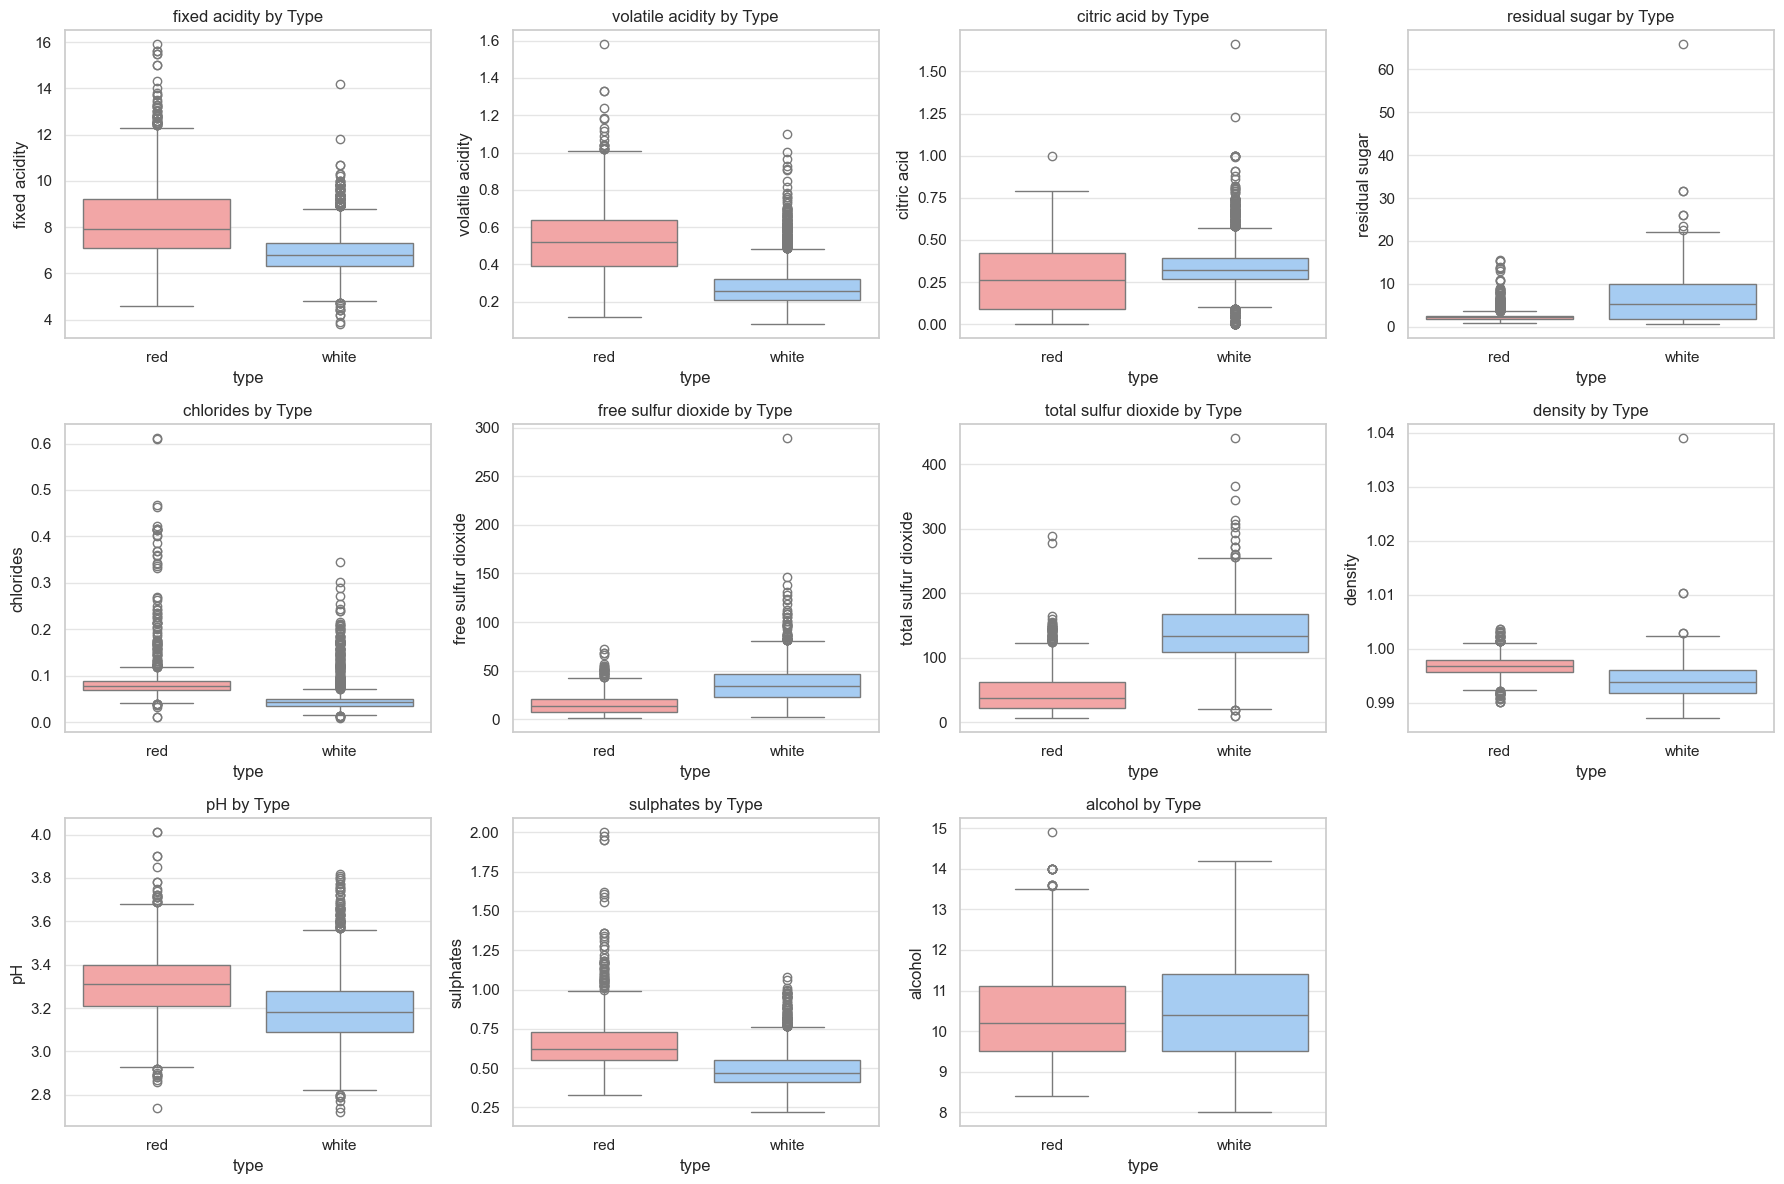

In [8]:
display(wine_data.describe())

features = wine_data.columns[:-2] # Exclude 'quality' and 'type'

plt.figure(figsize=(18, 12))
for i, col in enumerate(features):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x='type', y=col, data=wine_data, palette={'red': '#FF9999', 'white': '#99CCFF'})
    plt.title(f'{col} by Type')
plt.tight_layout()
plt.show()

### Anomaly Detection & Preprocessing
**Justification:** Distance-based algorithms like K-Means are highly sensitive to outliers and feature scales. 
1. **Outlier Removal:** We use the Z-score method (threshold = 3) to filter out extreme outliers that might distort cluster centroids.
2. **Scaling:** We apply `StandardScaler` to the 11 chemical attributes. Features like `total sulfur dioxide` have significantly larger numerical ranges than `chlorides`. Standardizing ensures each feature contributes equally to the Euclidean distance calculations.

In [10]:
# 1. Anomaly Detection (Z-score method)
numerical_data = wine_data.drop(['quality', 'type'], axis=1)
z_scores = np.abs(stats.zscore(numerical_data))
filtered_entries = (z_scores < 3).all(axis=1)
wine_data_clean = wine_data[filtered_entries].copy()

print('Original dataset shape:', wine_data.shape)
print('Cleaned dataset shape:', wine_data_clean.shape)
print(f'Removed {wine_data.shape[0] - wine_data_clean.shape[0]} outlier rows.')

# 2. Preprocessing (Standard Scaling)
scaler = StandardScaler()
X_features = wine_data_clean.drop(['quality', 'type'], axis=1)
X_scaled = scaler.fit_transform(X_features)

# 3. Save cleaned data
wine_data_clean.to_csv('./processed_data/merged_cleaned_wine.csv', index=False)
print('Cleaned dataset saved to merged_cleaned_wine.csv')

Original dataset shape: (6497, 13)
Cleaned dataset shape: (6009, 13)
Removed 488 outlier rows.
Cleaned dataset saved to merged_cleaned_wine.csv


### K-Means Clustering
We apply K-Means with $k=2$ using the preprocessed chemical features to determine if the algorithm can naturally segment the data into 'Red' and 'White' groups.

In [11]:
# Perform K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
wine_data_clean['cluster'] = clusters

# Map clusters to wine types based on majority voting in each cluster
cluster_0_majority = wine_data_clean[wine_data_clean['cluster'] == 0]['type'].mode()[0]
cluster_1_majority = wine_data_clean[wine_data_clean['cluster'] == 1]['type'].mode()[0]
cluster_map = {0: cluster_0_majority, 1: cluster_1_majority}

wine_data_clean['predicted_type'] = wine_data_clean['cluster'].map(cluster_map)
print(f'Cluster 0 predominantly contains: {cluster_0_majority}')
print(f'Cluster 1 predominantly contains: {cluster_1_majority}')

Cluster 0 predominantly contains: red
Cluster 1 predominantly contains: white


### Evaluation & Results Summary
We compare the K-Means assigned clusters to the actual ground truth labels using a Confusion Matrix, Accuracy, and Sensitivity.

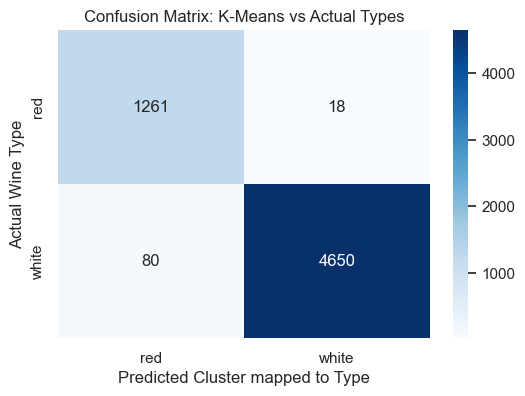

--- Clustering Performance Summary ---
Classification Accuracy: 98.37%
Sensitivity (Red Wine): 98.59%
Sensitivity (White Wine): 98.31%


In [12]:
y_true = wine_data_clean['type']
y_pred = wine_data_clean['predicted_type']

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=['red', 'white'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['red', 'white'], yticklabels=['red', 'white'])
plt.xlabel('Predicted Cluster mapped to Type')
plt.ylabel('Actual Wine Type')
plt.title('Confusion Matrix: K-Means vs Actual Types')
plt.show()

# Metrics
accuracy = accuracy_score(y_true, y_pred)
sensitivity_red = recall_score(y_true, y_pred, pos_label='red')
sensitivity_white = recall_score(y_true, y_pred, pos_label='white')

print('--- Clustering Performance Summary ---')
print(f'Classification Accuracy: {accuracy * 100:.2f}%')
print(f'Sensitivity (Red Wine): {sensitivity_red * 100:.2f}%')
print(f'Sensitivity (White Wine): {sensitivity_white * 100:.2f}%')